# Targeted Containment Analysis 

Compares 100% outbound halt from corrected containment perimeters at 4 timings.

**Output:** `S_TargetedContainment.png/.pdf`

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from pathlib import Path
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})
for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        plt.rcParams['font.family'] = font
        break
    except:
        pass

PROJ_ROOT = Path('../..').resolve()
PAPER_DIR = PROJ_ROOT / 'paper' / 'final'
SIM_DIR = PROJ_ROOT / 'analysis' / 'simulations'
CONTAINMENT_DIR = PAPER_DIR / 'analysis' / 'simulations' / 'results' / 'containment_v3'
BASELINE_DIR = PAPER_DIR / 'analysis' / 'simulations' / 'results' / 'baseline'
FIG_DIR = PAPER_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

with open(SIM_DIR / 'config.yaml') as f:
    config = yaml.safe_load(f)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print(f'CONTAINMENT_DIR: {CONTAINMENT_DIR}')
print(f'BASELINE_DIR: {BASELINE_DIR}')
print(f'FIG_DIR: {FIG_DIR}')

CONTAINMENT_DIR: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/analysis/simulations/results/containment_v3
BASELINE_DIR: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/analysis/simulations/results/baseline
FIG_DIR: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures


## Define perimeters and timings

In [2]:
county_sets = config.get('county_sets', {})

PERIMETERS = [
    ('panhandle',        'Panhandle',                   len(county_sets.get('panhandle', [])),        'Local'),
    ('geo_ring2',        '2-county buffer',             len(county_sets.get('geo_ring2', [])),        'Geographic'),
    ('geo_ring4',        '4-county buffer',             len(county_sets.get('geo_ring4', [])),        'Geographic'),
    ('net99_1hop',       '1-link network perimeter',    len(county_sets.get('net99_1hop', [])),       'Network'),
    ('net99_2hop_cond',  '2-link network perimeter',    len(county_sets.get('net99_2hop_cond', [])),  'Network'),
    ('tx_region7',       'TX + 6 nearby states (437)',          None,                                        'Regional'),
]

TIMINGS = ['tmrca14', 'tmrca30', 'tmrca60', 'detect']
TIMING_LABELS = {
    'tmrca14': 'tMRCA + 14d',
    'tmrca30': 'tMRCA + 30d',
    'tmrca60': 'tMRCA + 60d',
    'detect': 'TX detection',
}

GROUP_COLORS = {
    'Local': '#888888',
    'Network': '#2166ac',
    'Geographic': '#b2182b',
    'Regional': '#4daf4a',
}

for pkey, plabel, psize, cat in PERIMETERS:
    size_str = str(psize) if psize else 'state-level'
    print(f'  {pkey}: {plabel} ({size_str} counties) [{cat}]')

  panhandle: Panhandle (14 counties) [Local]
  geo_ring2: 2-county buffer (47 counties) [Geographic]
  geo_ring4: 4-county buffer (111 counties) [Geographic]
  net99_1hop: 1-link network perimeter (41 counties) [Network]
  net99_2hop_cond: 2-link network perimeter (102 counties) [Network]
  tx_region7: TX + 6 nearby states (437) (state-level counties) [Regional]


## Load data

In [3]:
data = {}
missing = []

for pkey, plabel, psize, cat in PERIMETERS:
    for t in TIMINGS:
        sc = f'{pkey}_halt_{t}'
        fp = CONTAINMENT_DIR / f'{sc}_results.csv'
        if fp.exists():
            data[sc] = pd.read_csv(fp)
            print(f'{sc}: {len(data[sc]):,} sims')
        else:
            missing.append(sc)

# Baselines
for sc in ['no_npi', 'npi_day35']:
    fp = BASELINE_DIR / f'{sc}_results.csv'
    data[sc] = pd.read_csv(fp)
    print(f'{sc}: {len(data[sc]):,} sims')

if missing:
    print(f'\nMISSING ({len(missing)}): {missing}')

panhandle_halt_tmrca14: 375,000 sims
panhandle_halt_tmrca30: 375,000 sims
panhandle_halt_tmrca60: 375,000 sims
panhandle_halt_detect: 375,000 sims
geo_ring2_halt_tmrca14: 375,000 sims
geo_ring2_halt_tmrca30: 375,000 sims
geo_ring2_halt_tmrca60: 375,000 sims
geo_ring2_halt_detect: 375,000 sims
geo_ring4_halt_tmrca14: 375,000 sims
geo_ring4_halt_tmrca30: 375,000 sims
geo_ring4_halt_tmrca60: 375,000 sims
geo_ring4_halt_detect: 375,000 sims
net99_1hop_halt_tmrca14: 375,000 sims
net99_1hop_halt_tmrca30: 375,000 sims
net99_1hop_halt_tmrca60: 375,000 sims
net99_1hop_halt_detect: 375,000 sims
net99_2hop_cond_halt_tmrca14: 375,000 sims
net99_2hop_cond_halt_tmrca30: 375,000 sims
net99_2hop_cond_halt_tmrca60: 375,000 sims
net99_2hop_cond_halt_detect: 375,000 sims
tx_region7_halt_tmrca14: 375,000 sims
tx_region7_halt_tmrca30: 375,000 sims
tx_region7_halt_tmrca60: 375,000 sims
tx_region7_halt_detect: 375,000 sims
no_npi: 375,000 sims
npi_day35: 375,000 sims


## Heatmap figure

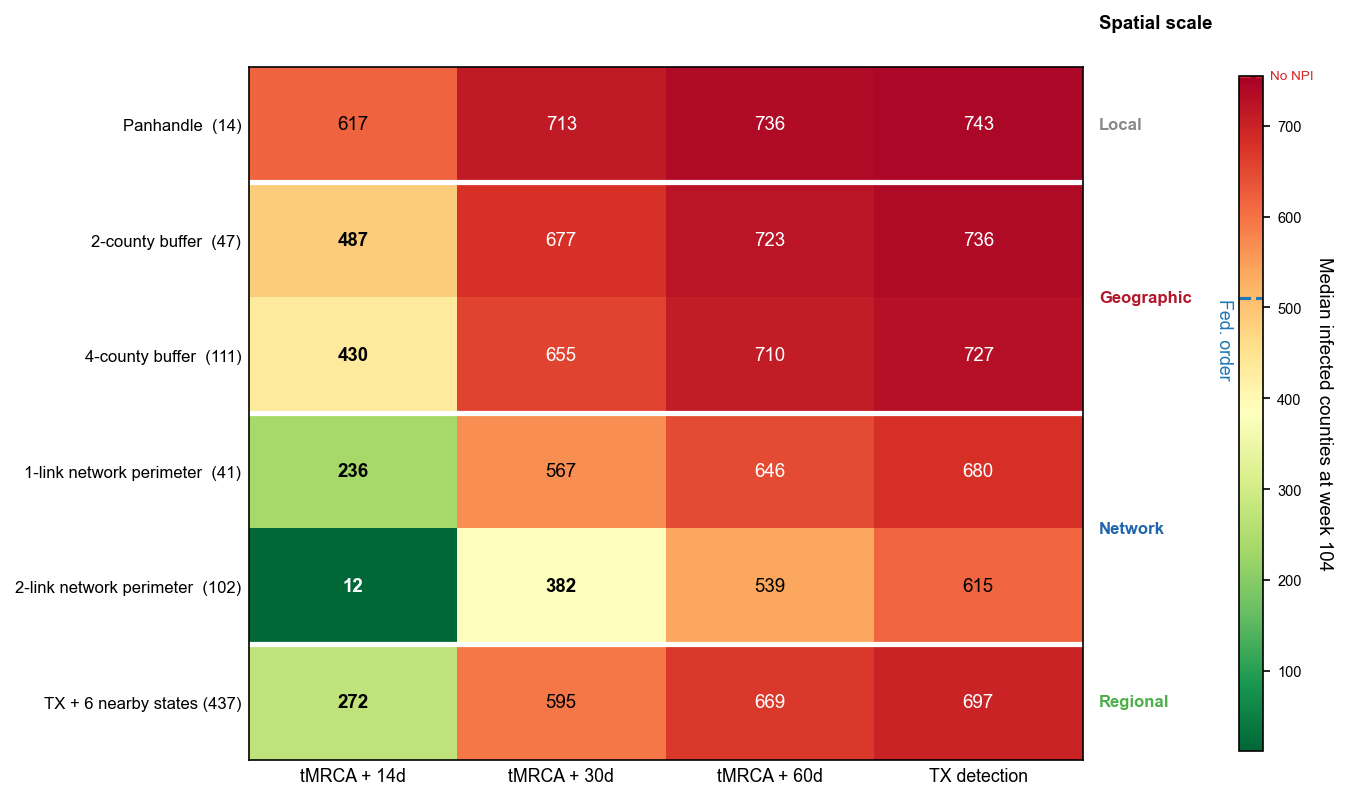

In [4]:
# Filter to perimeters with data
avail_perimeters = []
for pkey, plabel, psize, cat in PERIMETERS:
    sc_test = f'{pkey}_halt_tmrca14'
    if sc_test in data:
        avail_perimeters.append((pkey, plabel, psize, cat))

# Sort by category order then county count
CAT_ORDER = {'Local': 0, 'Geographic': 1, 'Network': 2, 'Regional': 3}
avail_perimeters.sort(key=lambda x: (CAT_ORDER[x[3]], x[2] or 9999))

n_rows = len(avail_perimeters)
n_cols = len(TIMINGS)

# Build heatmap array
heatmap = np.zeros((n_rows, n_cols))
for i, (pkey, plabel, psize, cat) in enumerate(avail_perimeters):
    for j, t in enumerate(TIMINGS):
        sc = f'{pkey}_halt_{t}'
        heatmap[i, j] = np.median(data[sc]['counties_w104'].values)

# Baselines
no_npi_median = np.median(data['no_npi']['counties_w104'].values)
fed_order_median = np.median(data['npi_day35']['counties_w104'].values)

# Color scale
vmin = heatmap.min()
vmax = max(heatmap.max(), no_npi_median)
cmap = plt.cm.RdYlGn_r
norm = Normalize(vmin=vmin, vmax=vmax)

# Find group boundaries
def find_group_boundaries(perims):
    groups = []
    cur_group = perims[0][3]
    cur_start = 0
    for i, (_, _, _, grp) in enumerate(perims):
        if grp != cur_group:
            groups.append((cur_start, i - 1, cur_group))
            cur_group = grp
            cur_start = i
    groups.append((cur_start, len(perims) - 1, cur_group))
    return groups

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(heatmap, cmap=cmap, norm=norm, aspect='auto')

for i in range(n_rows):
    for j in range(n_cols):
        val = heatmap[i, j]
        rgba = cmap(norm(val))
        lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        tc = 'white' if lum < 0.5 else 'black'
        fw = 'bold' if val <= fed_order_median else 'normal'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=9, fontweight=fw, color=tc)

# Row labels with county count
row_labels = []
for pkey, plabel, psize, cat in avail_perimeters:
    if psize:
        row_labels.append(f'{plabel}  ({psize})')
    else:
        row_labels.append(plabel)

ax.set_yticks(range(n_rows))
ax.set_yticklabels(row_labels, fontsize=8)
ax.set_xticks(range(n_cols))
ax.set_xticklabels([TIMING_LABELS[t] for t in TIMINGS], fontsize=8.5)
ax.tick_params(length=0)

# "Spatial scale" header above the right-side group labels
groups = find_group_boundaries(avail_perimeters)
ax.annotate('Spatial scale', xy=(1.02, 1.05), xycoords='axes fraction',
            fontsize=9, fontweight='bold', ha='left', va='bottom')

# Group separators + right-side labels
for start, end, grp in groups:
    if start > 0:
        ax.axhline(start - 0.5, color='white', lw=2.5)
    mid = (start + end) / 2
    ax.annotate(grp, xy=(1.02, mid), xycoords=('axes fraction', 'data'),
                fontsize=8, fontweight='bold', color=GROUP_COLORS[grp],
                ha='left', va='center')

# Colorbar — shifted right for more spacing
cax = fig.add_axes([0.95, 0.12, 0.02, 0.75])
cb = fig.colorbar(im, cax=cax)
cb.set_label('Median infected counties at week 104', fontsize=9, rotation=270, labelpad=15)
cb.ax.tick_params(labelsize=7)

cb.ax.axhline(no_npi_median, color='#d62728', ls='--', lw=1.5)
cb.ax.text(1.3, no_npi_median, 'No NPI', transform=cb.ax.get_yaxis_transform(),
           fontsize=6.5, color='#d62728', va='center')

cb.ax.axhline(fed_order_median, color='#1f77b4', ls='--', lw=1.5)
cb.ax.text(-1, fed_order_median, 'Fed. order',
           transform=cb.ax.get_yaxis_transform(),
           fontsize=8.5, color='#1f77b4', va='top', ha='left', rotation=-90,
           clip_on=False)

fig.subplots_adjust(right=0.82)

# fig.savefig(FIG_DIR / 'S_TargetedContainment.png')
# fig.savefig(FIG_DIR / 'S_TargetedContainment.pdf')
plt.show()
# print(f'Saved to {FIG_DIR / "S_TargetedContainment"}.png/.pdf')

## Summary statistics

In [5]:
print(f'No-NPI baseline: median = {no_npi_median:.0f} counties')
print(f'Federal order (posterior): median = {fed_order_median:.0f} counties')
print()
print(f'{"Perimeter":<25} {"Size":>5} {"Timing":<14} {"Median":>7} {"IQR":>16} {"95% PI":>16} {"vs Fed":>8}')
print('-'*100)

prev_pkey = None
for pkey, plabel, psize, cat in avail_perimeters:
    if pkey != prev_pkey:
        if prev_pkey is not None:
            print()
        prev_pkey = pkey
    for t in TIMINGS:
        sc = f'{pkey}_halt_{t}'
        vals = data[sc]['counties_w104'].values
        med = np.median(vals)
        q25, q75 = np.percentile(vals, [25, 75])
        q025, q975 = np.percentile(vals, [2.5, 97.5])
        diff = (med - fed_order_median) / fed_order_median * 100
        marker = ' ***' if med <= fed_order_median else ''
        size_str = str(psize) if psize else 'state'
        print(f'{plabel:<25} {size_str:>5} {TIMING_LABELS[t]:<14} {med:>7.0f} '
              f'[{q25:>5.0f}, {q75:>5.0f}] [{q025:>5.0f}, {q975:>5.0f}] {diff:>+7.1f}%{marker}')

No-NPI baseline: median = 755 counties
Federal order (posterior): median = 510 counties

Perimeter                  Size Timing          Median              IQR           95% PI   vs Fed
----------------------------------------------------------------------------------------------------
Panhandle                    14 tMRCA + 14d        617 [  237,   991] [    1,  1459]   +21.0%
Panhandle                    14 tMRCA + 30d        713 [  416,  1030] [    4,  1468]   +39.8%
Panhandle                    14 tMRCA + 60d        736 [  444,  1037] [   83,  1470]   +44.3%
Panhandle                    14 TX detection       743 [  451,  1041] [  124,  1471]   +45.7%

2-county buffer              47 tMRCA + 14d        487 [    6,   913] [    1,  1437]    -4.5% ***
2-county buffer              47 tMRCA + 30d        677 [  362,  1010] [    3,  1454]   +32.7%
2-county buffer              47 tMRCA + 60d        723 [  433,  1025] [   20,  1459]   +41.8%
2-county buffer              47 TX detection     

## Break-even analysis

In [6]:
print(f'Federal order median: {fed_order_median:.0f} counties')
print()

beats = []
for pkey, plabel, psize, cat in avail_perimeters:
    for t in TIMINGS:
        sc = f'{pkey}_halt_{t}'
        med = np.median(data[sc]['counties_w104'].values)
        if med <= fed_order_median:
            red = (fed_order_median - med) / fed_order_median * 100
            beats.append((sc, plabel, psize or 0, t, med, red))

beats.sort(key=lambda x: x[4])
print(f'Scenarios that outperform federal order: {len(beats)}')
print(f'{"Scenario":<35} {"Median":>8} {"Zone size":>10} {"Reduction":>10}')
print('-'*70)
for sc, plabel, psize, t, med, red in beats:
    print(f'{sc:<35} {med:>8.0f} {psize:>10} {red:>+9.1f}%')

Federal order median: 510 counties

Scenarios that outperform federal order: 6
Scenario                              Median  Zone size  Reduction
----------------------------------------------------------------------
net99_2hop_cond_halt_tmrca14              12        102     +97.6%
net99_1hop_halt_tmrca14                  236         41     +53.7%
tx_region7_halt_tmrca14                  272          0     +46.7%
net99_2hop_cond_halt_tmrca30             382        102     +25.1%
geo_ring4_halt_tmrca14                   430        111     +15.7%
geo_ring2_halt_tmrca14                   487         47      +4.5%
